# Lecture 2 — Foundations of Supervised Learning
## Lab Notebook · Deep Learning · UCU

---

### Overview

In this lab you will move from the mathematical ideas of Lecture 2 to working code. The notebook is organized in three parts that build on each other:

1. **Statistical intuitions with PyTorch** — sample from distributions, estimate expectations empirically, and observe how estimation error shrinks as you collect more data (the Law of Large Numbers).
2. **Linear regression from scratch** — implement MSE loss and gradient descent by hand on synthetic data, then visualize the loss landscape and training trajectory.
3. **Linear regression on a real dataset** — apply the same ideas to the California Housing dataset using `torch.nn` and `torch.optim`.

There is also an **optional** section at the end where you apply linear regression to FashionMNIST images and see what happens.

### Useful References

- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- [`torch.distributions`](https://pytorch.org/docs/stable/distributions.html) — probability distributions in PyTorch
- [`torch.nn`](https://pytorch.org/docs/stable/nn.html) — neural network building blocks
- [`torch.optim`](https://pytorch.org/docs/stable/optim.html) — optimization algorithms
- [California Housing dataset (sklearn)](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
- [FashionMNIST (torchvision)](https://pytorch.org/vision/stable/datasets.html#fashion-mnist)
- *Understanding Deep Learning* — Prince (2023), Chapters 2, Appendices A–C

> **Estimated time:** 1.5–2 hours for Parts 1–3. The optional section is take-home work.

## Setup

Run the cell below to install dependencies and import everything you will need.

In [1]:
# Install dependencies (only needed if running outside the course environment)
# !pip install torch torchvision scikit-learn pandas matplotlib numpy --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# UCU color palette
C1 = '#19326E'  # dark blue
C2 = '#50ACB0'  # teal
C3 = '#CD742A'  # orange
C4 = '#A3477F'  # purple

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.10.0+cu128


---
## Part 1 — Statistical Intuitions with PyTorch

Before building any model, we revisit two core probabilistic ideas from the lecture:

- **Expectation** can be estimated by sampling: $\mathbb{E}_x[f[x]] \approx \frac{1}{N}\sum_{i=1}^{N} f[x_i]$, where $x_i \sim \Pr(x)$.
- **Law of Large Numbers:** the sample mean converges to the true mean as $N \to \infty$, and the estimation error decreases roughly as $\sigma/\sqrt{N}$.

### 1.1 Estimating Expectations by Sampling

Consider $x \sim \mathcal{N}(0, 1)$. We want to estimate $\mathbb{E}[x^2]$.
Analytically: $\mathbb{E}[x^2] = \text{Var}(x) + (\mathbb{E}[x])^2 = 1 + 0 = 1$.

Below, we confirm this by drawing samples of increasing size.

In [2]:
mu, sigma = 0.0, 1.0
analytical_value = sigma**2 + mu**2  # E[x²] = Var(x) + E[x]² = 1

print(f'Analytical E[x²] = {analytical_value:.4f}\n')
print(f'{"N":>8}   {"Estimate":>10}   {"Abs. Error":>12}')
print('-' * 40)

for N in [10, 100, 1_000, 10_000, 100_000]:
    samples = torch.normal(mean=mu, std=sigma, size=(N,))
    estimate = (samples ** 2).mean().item()
    error = abs(estimate - analytical_value)
    print(f'{N:>8}   {estimate:>10.4f}   {error:>12.4f}')

Analytical E[x²] = 1.0000

       N     Estimate     Abs. Error
----------------------------------------
      10       0.7101         0.2899
     100       0.8432         0.1568
    1000       0.9362         0.0638
   10000       1.0037         0.0037
  100000       1.0112         0.0112


> **Question 1.1** — As $N$ grows by a factor of 10, approximately how does the error change? Is the relationship linear, or does the error decrease more slowly? What does that tell you about the cost of halving the estimation error?

> *Your answer here:* El error va disminuyendo cada vez más lento (disminuye en 1300, 900, 600 aprox.) hasta llegar a 10000, sin embargo empieza a aumentar al alcanzar 100000.

### 1.2 Exercise — Law of Large Numbers

In the cell below, implement `compute_mean_error`. This function should measure how accurately we can estimate the **mean** of a Gaussian distribution from a finite sample, averaged over many independent trials.

**Hint:** `torch.normal(mean, std, size=(n_trials, N))` returns a tensor of shape `(n_trials, N)` — `n_trials` independent batches of `N` samples each.

In [ ]:
def compute_mean_error(mu, sigma, N_values, n_trials=500):
    """
    For each N in N_values, estimate the average absolute error when
    estimating the mean of N(mu, sigma) using N samples.

    For each N:
      1. Draw n_trials independent batches of N samples from N(mu, sigma).
      2. Compute the sample mean of each batch.
      3. Compute |sample_mean - mu| for each trial.
      4. Return the average of those absolute errors across all trials.

    Args:
        mu        (float): true mean
        sigma     (float): true standard deviation
        N_values  (list[int]): sample sizes to evaluate
        n_trials  (int): number of independent trials per sample size

    Returns:
        torch.Tensor of shape (len(N_values),): mean absolute errors
    """
    errors = []
    for N in N_values:
        samples = torch.normal(mean=mu, std=sigma, size=(n_trials, N))
        sample_means = samples.mean(dim=1)
        abs_errors = (sample_means - mu).abs()
        mean_error = abs_errors.mean()
        errors.append(mean_error.item())
    return torch.tensor(errors)

# Quick sanity check — error should decrease as N grows
test_errors = compute_mean_error(0.0, 1.0, [10, 100, 1000])
print('Mean absolute errors for N = [10, 100, 1000]:', test_errors.tolist())

Mean absolute errors for N = [10, 100, 1000]: [0.25361672043800354, 0.08227825164794922, 0.025165537372231483]


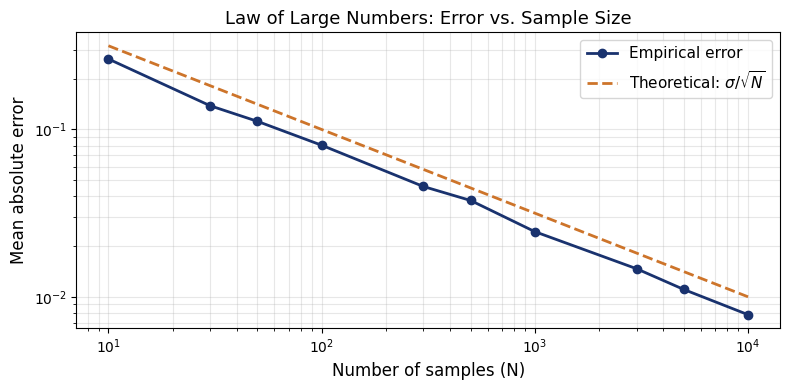

In [11]:
# Run and plot — this cell uses your function from above
N_values = [10, 30, 50, 100, 300, 500, 1_000, 3_000, 5_000, 10_000]
errors = compute_mean_error(mu=0.0, sigma=1.0, N_values=N_values, n_trials=500)

# Theoretical upper bound: E[|mean - mu|] ≈ sigma / sqrt(N)
theoretical = torch.tensor([1.0 / N**0.5 for N in N_values])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N_values, errors.numpy(), 'o-', color=C1, lw=2, label='Empirical error')
ax.plot(N_values, theoretical.numpy(), '--', color=C3, lw=2,
        label=r'Theoretical: $\sigma / \sqrt{N}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of samples (N)', fontsize=12)
ax.set_ylabel('Mean absolute error', fontsize=12)
ax.set_title('Law of Large Numbers: Error vs. Sample Size', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

> **Question 1.2** — Looking at the plot:
> - What is the slope of the error curve on the log-log axes?
> - How many samples would you need (roughly) to reduce the error below 0.01?

> *Your answer here.*
> - Cuando aumenta el tamaño de la muestra, disminuye el tamaño del error.
> - Necesitas entre 10^3 y 10^4 para alcanzar 0.01 (10^-2 en el eje y).

---
## Part 2 — Linear Regression from Scratch

In the lecture we saw that training a linear model means solving:

$$\hat{\boldsymbol{\phi}} = \underset{\boldsymbol{\phi}}{\text{argmin}}\; L[\boldsymbol{\phi}] = \underset{\phi_0, \phi_1}{\text{argmin}} \frac{1}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)^2$$

We will implement this step by step: loss → gradients → gradient descent.

### 2.1 Synthetic Data

We generate data from a known line $y = \phi_0^* + \phi_1^* x + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, 0.8)$. Because we know the true parameters, we can check how close gradient descent gets.

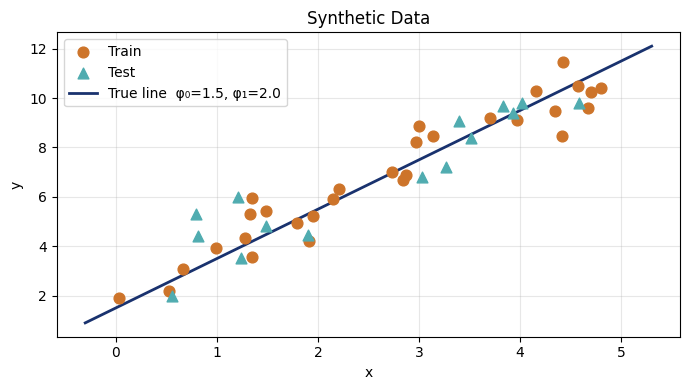

Train size: 30   Test size: 15


In [14]:
torch.manual_seed(42)

# True (unknown to the model) parameters
phi_0_true = 1.5
phi_1_true = 2.0

N_train, N_test = 30, 15

x_train = torch.rand(N_train) * 5          # uniform in [0, 5]
y_train = phi_0_true + phi_1_true * x_train + torch.randn(N_train) * 0.8

x_test = torch.rand(N_test) * 5
y_test = phi_0_true + phi_1_true * x_test + torch.randn(N_test) * 0.8

x_line = torch.linspace(-0.3, 5.3, 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_train.numpy(), y_train.numpy(), color=C3, s=60, zorder=5, label='Train')
ax.scatter(x_test.numpy(),  y_test.numpy(),  color=C2, s=60, zorder=5, marker='^', label='Test')
ax.plot(x_line.numpy(), (phi_0_true + phi_1_true * x_line).numpy(),
        color=C1, lw=2, label=f'True line  φ₀={phi_0_true}, φ₁={phi_1_true}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Synthetic Data')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Train size: {N_train}   Test size: {N_test}')

### 2.2 Exercise — MSE Loss

Implement the Mean Squared Error loss for a linear model $\hat{y} = \phi_0 + \phi_1 x$:

$$L[\phi_0, \phi_1] = \frac{1}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)^2$$

In [13]:
def mse_loss(phi_0, phi_1, x, y):
    """
    Mean Squared Error loss for linear model y_hat = phi_0 + phi_1 * x.

    Args:
        phi_0 (float): intercept
        phi_1 (float): slope
        x (torch.Tensor): inputs, shape (N,)
        y (torch.Tensor): targets, shape (N,)

    Returns:
        float: MSE loss
    """
    # YOUR CODE HERE
    raise NotImplementedError("Implement mse_loss!")


# Sanity check
loss_true = mse_loss(phi_0_true, phi_1_true, x_train, y_train)
loss_zero = mse_loss(0.0, 0.0, x_train, y_train)
print(f'Loss with TRUE parameters:  {loss_true:.4f}')
print(f'Loss with ZERO parameters:  {loss_zero:.4f}')
print('True params should give a smaller loss.')

NotImplementedError: Implement mse_loss!

In [ ]:
# Visualize the loss surface — uses your mse_loss function
phi_0_range = torch.linspace(-1.0, 4.0, 80)
phi_1_range = torch.linspace(0.0,  4.0, 80)
P0, P1 = torch.meshgrid(phi_0_range, phi_1_range, indexing='ij')

loss_surface = torch.zeros_like(P0)
for i in range(P0.shape[0]):
    for j in range(P0.shape[1]):
        loss_surface[i, j] = mse_loss(P0[i, j].item(), P1[i, j].item(), x_train, y_train)

fig, ax = plt.subplots(figsize=(6, 5))
contour = ax.contourf(P0.numpy(), P1.numpy(), loss_surface.numpy(), levels=40, cmap='viridis')
ax.scatter([phi_0_true], [phi_1_true], color='white', s=120, zorder=5,
           marker='*', label='True params')
plt.colorbar(contour, ax=ax, label='MSE Loss')
ax.set_xlabel('φ₀ (intercept)', fontsize=12)
ax.set_ylabel('φ₁ (slope)', fontsize=12)
ax.set_title('Loss Surface', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Question 2.1** — Look at the loss surface contour plot. Is this function convex? What does that imply for gradient descent?

*Your answer here.*

### 2.3 Exercise — Gradient Descent

Implement gradient descent **without** autograd. Use the analytic gradients of the MSE loss:

$$\frac{\partial L}{\partial \phi_0} = \frac{2}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)$$

$$\frac{\partial L}{\partial \phi_1} = \frac{2}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i) \cdot x_i$$

Update rule: $\phi_k \leftarrow \phi_k - \alpha \cdot \frac{\partial L}{\partial \phi_k}$

In [ ]:
def gradient_descent(x, y, lr=0.01, n_steps=600):
    """
    Fit a linear model y = phi_0 + phi_1*x by gradient descent.

    Args:
        x       (torch.Tensor): inputs,  shape (N,)
        y       (torch.Tensor): targets, shape (N,)
        lr      (float): learning rate
        n_steps (int): number of gradient descent steps

    Returns:
        phi_0   (float): learned intercept
        phi_1   (float): learned slope
        history (list[tuple]): (phi_0, phi_1, loss) recorded at every step
    """
    phi_0, phi_1 = 0.0, 0.0
    N = len(x)
    history = []

    for step in range(n_steps):
        # YOUR CODE HERE
        # 1. Compute predictions: y_hat = phi_0 + phi_1 * x
        # 2. Compute residuals:   residuals = y_hat - y
        # 3. Compute gradients (see formulas above)
        # 4. Update parameters
        # 5. Record (phi_0, phi_1, loss) in history — use your mse_loss function
        raise NotImplementedError("Implement gradient_descent!")

    return phi_0, phi_1, history


phi_0_hat, phi_1_hat, history = gradient_descent(x_train, y_train, lr=0.01, n_steps=600)
print(f'Learned:  φ₀ = {phi_0_hat:.4f},  φ₁ = {phi_1_hat:.4f}')
print(f'True:     φ₀ = {phi_0_true:.4f},  φ₁ = {phi_1_true:.4f}')

In [ ]:
# Visualize training — uses your gradient_descent output
phis_0 = [h[0] for h in history]
phis_1 = [h[1] for h in history]
losses = [h[2] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss curve
axes[0].plot(losses, color=C1, lw=2)
axes[0].set_xlabel('Step', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Trajectory on loss surface
contour = axes[1].contourf(P0.numpy(), P1.numpy(), loss_surface.numpy(),
                            levels=40, cmap='viridis', alpha=0.85)
axes[1].plot(phis_0, phis_1, 'w-', lw=1.2, alpha=0.7, label='GD path')
axes[1].scatter([phis_0[0]], [phis_1[0]], color='red',   s=80, zorder=5, label='Start (0, 0)')
axes[1].scatter([phi_0_hat], [phi_1_hat], color='white', s=120, zorder=5, marker='*', label='Learned')
axes[1].scatter([phi_0_true],[phi_1_true], color=C3,    s=120, zorder=5, marker='*', label='True')
axes[1].set_xlabel('φ₀', fontsize=12); axes[1].set_ylabel('φ₁', fontsize=12)
axes[1].set_title('Gradient Descent Trajectory', fontsize=13)
axes[1].legend(fontsize=9)
plt.colorbar(contour, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# Fitted line on train and test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, xd, yd, col in [
    (axes[0], 'Training set', x_train, y_train, C3),
    (axes[1], 'Test set',     x_test,  y_test,  C2),
]:
    ax.scatter(xd.numpy(), yd.numpy(), color=col, s=60, zorder=5, label='Data')
    ax.plot(x_line.numpy(), (phi_0_true + phi_1_true * x_line).numpy(),
            color='gray', lw=2, linestyle='--', label='True line')
    ax.plot(x_line.numpy(), (phi_0_hat + phi_1_hat * x_line).numpy(),
            color=C1, lw=2, label='Fitted line')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

train_mse = mse_loss(phi_0_hat, phi_1_hat, x_train, y_train)
test_mse  = mse_loss(phi_0_hat, phi_1_hat, x_test,  y_test)
print(f'Train MSE: {train_mse:.4f}')
print(f'Test  MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

> **Question 2.2** — Is the test MSE higher or lower than the train MSE? Why would you expect that?

*Your answer here.*

---
## Part 3 — Linear Regression on a Real Dataset

Now we apply the same ideas to the **California Housing dataset** — a standard benchmark that predicts the median house value (in units of $100k) for census block groups in California, using 8 numerical features.

| Feature | Description |
|---------|-------------|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Block group population |
| `AveOccup` | Average household occupancy |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |

This time we will use **`torch.nn.Linear`** and **`torch.optim.Adam`** instead of handcrafted loops.

### 3.1 Load and Explore the Data

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f'Shape: {df.shape}')
print(f'Features: {housing.feature_names}')
df.head()

In [ ]:
df.describe()

In [ ]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MedHouseVal'].values, bins=50, color=C1, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Median House Value ($100k)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Target Distribution', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Scatter: income vs. price (strongest linear predictor)
axes[1].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5, color=C2)
axes[1].set_xlabel('Median Income', fontsize=11)
axes[1].set_ylabel('Median House Value ($100k)', fontsize=11)
axes[1].set_title('Income vs. House Value', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('Pearson correlation with target (MedHouseVal):')
print(corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False).to_string())

> **Question 3.1** — Which feature has the strongest linear correlation with the house value? Are there any features that are negatively correlated? Does that make intuitive sense?

*Your answer here.*

### 3.2 Preprocessing

In [ ]:
X = df[housing.feature_names].values
y = df['MedHouseVal'].values

# Train / test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features: zero mean, unit variance (fit on train only!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_test_sc  = scaler.transform(X_test_np)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1)

print(f'X_train: {X_train_t.shape}   y_train: {y_train_t.shape}')
print(f'X_test:  {X_test_t.shape}    y_test:  {y_test_t.shape}')
print(f'Target range: [{y_train_t.min():.2f}, {y_train_t.max():.2f}]  ($100k units)')

### 3.3 Exercise — Build and Train the Model

Using `torch.nn.Linear` and `torch.optim.Adam`, implement the training loop below.

The model is a single linear layer: **8 inputs → 1 output**, trained with MSE loss in mini-batches.

**Steps inside each epoch:**
1. Set the model to training mode: `model.train()`
2. For each batch from `train_loader`:
   - Zero gradients: `optimizer.zero_grad()`
   - Forward pass: `predictions = model(X_batch)`
   - Compute loss: `loss = criterion(predictions, y_batch)`
   - Backward pass: `loss.backward()`
   - Update weights: `optimizer.step()`
3. After all batches, evaluate on both train and test sets using `model.eval()` and `torch.no_grad()`.
4. Append the evaluation losses to `train_losses` and `test_losses`.

In [ ]:
# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Model, loss, optimizer
model     = nn.Linear(X_train_t.shape[1], 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs = 60
train_losses = []
test_losses  = []

for epoch in range(n_epochs):
    # YOUR CODE HERE
    raise NotImplementedError("Implement the training loop!")

print(f'Final Train MSE: {train_losses[-1]:.4f}')
print(f'Final Test  MSE: {test_losses[-1]:.4f}')

In [ ]:
# Evaluate and plot
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()
    y_true = y_test_t.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training curves
axes[0].plot(train_losses, color=C1, lw=2, label='Train MSE')
axes[0].plot(test_losses,  color=C3, lw=2, label='Test MSE')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('MSE  (×$100k²)', fontsize=11)
axes[0].set_title('Training Progress', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs. actual
lim = [min(y_true.min(), y_pred.min()) - 0.1,
       max(y_true.max(), y_pred.max()) + 0.1]
axes[1].scatter(y_true, y_pred, alpha=0.2, s=6, color=C2)
axes[1].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('True Value ($100k)', fontsize=11)
axes[1].set_ylabel('Predicted ($100k)', fontsize=11)
axes[1].set_title('Predicted vs. True (Test Set)', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# R² score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(test_losses[-1])

print(f'R²   on test set: {r2:.4f}')
print(f'RMSE on test set: ${rmse * 100:.0f}k')

> **Question 3.2** — Look at the predicted vs. true scatter plot.
> - Where does the model make the largest errors?
> - There is a hard cap in the data at $500k. How does this affect the model's predictions at the high end?
> - Given the R² value, would you deploy this model in production? What would you try next to improve it?

*Your answer here.*

In [ ]:
# Inspect learned weights — which features matter most?
weights = model.weight.data.squeeze().numpy()
bias    = model.bias.data.item()
feature_names = housing.feature_names

order = np.argsort(np.abs(weights))[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C1 if w >= 0 else C3 for w in weights[order]]
ax.barh([feature_names[i] for i in order], weights[order], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Learned Weight', fontsize=11)
ax.set_title(f'Model Weights  (bias = {bias:.3f})', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

> **Question 3.3** — Which features received the largest (absolute) weights? Does the sign of the weights make sense intuitively? Remember that the features are standardized, so the weights are comparable in magnitude.

*Your answer here.*

---
## Optional — Linear Regression on FashionMNIST

> This section is **not part of the 1–2 hour lab session**. Complete it at your own pace.

So far we have applied linear regression to problems where the relationship between input and output is (roughly) linear. What happens when we apply it to **images**?

FashionMNIST contains 70,000 grayscale images of clothing items (28×28 pixels, 10 categories). The plan:

1. Flatten each 28×28 image into a 784-dimensional vector.
2. Train a linear model with 10 outputs — one per class — using MSE on one-hot encoded labels.
3. Predict by taking the `argmax` of the 10 outputs.
4. Measure accuracy and analyze the confusion matrix.

This is not the right tool for the job — and seeing *how* it fails is the point.

In [ ]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # flatten 28×28 → 784
])

train_dataset_fm = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset_fm  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader_fm = DataLoader(train_dataset_fm, batch_size=256, shuffle=True)
test_loader_fm  = DataLoader(test_dataset_fm,  batch_size=256, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train samples: {len(train_dataset_fm)}')
print(f'Test  samples: {len(test_dataset_fm)}')
print(f'Input size:    {28}×{28} = {28*28} pixels')
print(f'Classes:       {len(class_names)}')

In [ ]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_fm[i]
    ax.imshow(img.view(28, 28).numpy(), cmap='gray')
    ax.set_title(class_names[label], fontsize=10)
    ax.axis('off')
plt.suptitle('FashionMNIST — Sample Images', fontsize=13)
plt.tight_layout()
plt.show()

### Exercise — Train a Linear Model on Images

Implement the training loop below.

**Model:** `nn.Linear(784, 10)` — maps each flattened image to 10 output scores.  
**Loss:** MSE between the model output and the **one-hot** encoded label vector.  
**Prediction:** `outputs.argmax(dim=1)` — the class with the highest score.

The helper `one_hot` is provided for you.

In [ ]:
def one_hot(labels, n_classes=10):
    """Convert integer labels to one-hot vectors."""
    return torch.zeros(len(labels), n_classes).scatter_(1, labels.unsqueeze(1), 1.0)


linear_model_fm = nn.Linear(28 * 28, 10)
criterion_fm    = nn.MSELoss()
optimizer_fm    = optim.Adam(linear_model_fm.parameters(), lr=0.01)

n_epochs_fm = 10
train_accs_fm = []
test_accs_fm  = []

for epoch in range(n_epochs_fm):
    # YOUR CODE HERE
    # Training:
    #   1. linear_model_fm.train()
    #   2. For each (images, labels) batch:
    #      a. Zero gradients
    #      b. Forward pass: outputs = linear_model_fm(images)
    #      c. targets = one_hot(labels)    <-- convert labels to one-hot
    #      d. Compute MSE loss between outputs and targets
    #      e. Backward + step
    #
    # Evaluation (do this for both train and test loaders):
    #   1. linear_model_fm.eval() + torch.no_grad()
    #   2. predicted = outputs.argmax(dim=1)
    #   3. accuracy  = (predicted == labels).float().mean().item()
    raise NotImplementedError("Implement the FashionMNIST training loop!")

print(f'Final Train Accuracy: {train_accs_fm[-1]:.2%}')
print(f'Final Test  Accuracy: {test_accs_fm[-1]:.2%}')

In [ ]:
from sklearn.metrics import confusion_matrix

# Accuracy curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs_fm, color=C1, lw=2, label='Train')
axes[0].plot(test_accs_fm,  color=C3, lw=2, label='Test')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Linear Regression on FashionMNIST', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Confusion matrix
linear_model_fm.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader_fm:
        preds = linear_model_fm(images).argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(class_names, fontsize=8)
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('True', fontsize=10)
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=12)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

### Visualize What the Model Learned

Each output neuron has 784 weights — one per pixel. We can reshape those weights back into a 28×28 image to see which pixels the model is "looking at" for each class.

In [ ]:
# The weight matrix has shape (10, 784) — one row per class
W = linear_model_fm.weight.data.numpy()  # shape: (10, 784)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    weight_img = W[i].reshape(28, 28)
    vmax = np.abs(weight_img).max()
    ax.imshow(weight_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(class_names[i], fontsize=10)
    ax.axis('off')
plt.suptitle('Learned Weights per Class  (red = positive, blue = negative)', fontsize=12)
plt.tight_layout()
plt.show()

> **Discussion Questions (Optional)**
>
> 1. What accuracy did the linear model achieve on FashionMNIST? Is that better than random guessing (10% for 10 classes)? What does that tell you?
> 2. Look at the confusion matrix. Which classes are most often confused with each other? Does that make sense visually?
> 3. Look at the weight images. Can you see the rough outline of each clothing item? What does it mean that the model learned these templates?
> 4. Why does a linear model fundamentally struggle with images, even if it does better than random? What property of images does it fail to exploit?
> 5. What kind of model would you try next to improve accuracy?

*Your answers here.*